In [17]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s"
)

BASE_URL = "https://krisha.kz/prodazha/kvartiry/?page="

CITY_LIST = [
    "Алматы", "Нур-Султан", "Астана", "Шымкент", "Караганда", "Актобе",
    "Павлодар", "Усть-Каменогорск", "Атырау", "Тараз", "Костанай",
    "Кызылорда", "Петропавловск", "Петропавл", "Орал", "Уральск", "Семей"
]

def clean_district_text(text):
    if not text:
        return text
    text = re.sub(r"\b(мкр\.?|мкр|ул\.?|улица|пр-т|проспект|шоссе|пос\.|площадь|д\.)\b.*", "", text, flags=re.I)
    return text.strip(" ,·")

def parse_location(raw_subtitle):
    if not raw_subtitle:
        return None
    text = raw_subtitle.replace("\xa0", " ").strip()
    parts = [p.strip() for p in text.split(",") if p.strip()]

    district = None
    for p in parts:
        if re.search(r"\bр-?н\b", p, flags=re.I) or re.search(r"\bрайон\b", p, flags=re.I):
            district = p
            break

    city = None
    for p in parts:
        for c in CITY_LIST:
            if re.search(rf"\b{re.escape(c)}\b", p, flags=re.I) or re.search(rf"\bг\.?\s*{re.escape(c)}\b", p, flags=re.I):
                city = c
                break
        if city:
            break

    if district:
        district_clean = clean_district_text(district)
        if city:
            return f"{city}, {district_clean}"
        else:
            return district_clean

    return None

def parse_floor_from_title(raw_title):
    if not raw_title:
        return None
    m = re.search(r"(\d+\s*/\s*\d+)\s*этаж", raw_title, flags=re.I)
    if m:
        return m.group(1).replace(" ", "")
    m2 = re.search(r"(?:этаж\s*(\d+)|\b(\d+)\s*этаж\b)", raw_title, flags=re.I)
    if m2:
        g = m2.group(1) or m2.group(2)
        return g
    return None

def parse_size(raw_title):
    m = re.search(r"(\d+(?:\.\d+)?)\s*м²", raw_title)
    if m:
        return f"{m.group(1)} м²"
    return None

def scrape_page(page_num):
    url = BASE_URL + str(page_num)
    logging.info(f"Запрос страницы {page_num}: {url}")
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")
    cards = soup.find_all("div", class_="a-card")
    logging.info(f"Найдено карточек: {len(cards)} на странице {page_num}")

    results = []
    for card in cards:
        raw_title = card.find("a", class_="a-card__title").get_text(strip=True) if card.find("a", class_="a-card__title") else None
        raw_price = card.find("div", class_="a-card__price").get_text(strip=True) if card.find("div", class_="a-card__price") else None
        raw_subtitle = card.find("div", class_="a-card__subtitle").get_text(strip=True) if card.find("div", class_="a-card__subtitle") else None

        property_type = None
        rooms = None
        if raw_title:
            property_type = raw_title.split("·")[0].strip()
            m = re.match(r"(\d+)-комнатная", property_type)
            if m:
                rooms = int(m.group(1))

        price = None
        if raw_price:
            price = int(re.sub(r"[^\d]", "", raw_price))
            price_with_currency = f"{price} ₸" if price else None

        size = parse_size(raw_title)
        floor = parse_floor_from_title(raw_title)
        location = parse_location(raw_subtitle)

        seller_tag = card.find("div", class_="a-card__owner")
        seller_type = "N/A"
        if seller_tag:
            seller_text = seller_tag.get_text(strip=True).lower()
            if "собственник" in seller_text or "owner" in seller_text:
                seller_type = "Owner"
            elif "риелтор" in seller_text or "realtor" in seller_text or "агент" in seller_text:
                seller_type = "Realtor"
            elif "застройщик" in seller_text or "developer" in seller_text:
                seller_type = "Developer"
            else:
                seller_type = "Other"

        results.append({
            "property_type": property_type,
            "price": price_with_currency,
            "size": size,
            "location": raw_subtitle,
            "rooms": rooms,
            "floor": floor,
            "title": raw_title,
            "seller_type": seller_type
        })
    return results

def scrape_all(pages=1200):
    all_results = []
    for p in range(1, pages + 1):
        all_results.extend(scrape_page(p))
        time.sleep(1)

    df = pd.DataFrame(all_results)
    logging.info(f"Всего записей (до удаления дублей): {len(df)}")

    df = df.dropna(how="any")
    logging.info(f"После удаления всех строк с пропусками: {len(df)}")

    df = df.reset_index(drop=True)
    df.index += 1

    df.to_csv("krisha_clean.csv", index=False, encoding="utf-8-sig")
    logging.info("Сохранено krisha_clean.csv")

    return df

if __name__ == "__main__":
    df = scrape_all(pages=1050)


2025-09-21 22:23:37,833 INFO Запрос страницы 1: https://krisha.kz/prodazha/kvartiry/?page=1
2025-09-21 22:23:39,442 INFO Найдено карточек: 23 на странице 1
2025-09-21 22:23:40,466 INFO Запрос страницы 2: https://krisha.kz/prodazha/kvartiry/?page=2
2025-09-21 22:23:42,071 INFO Найдено карточек: 20 на странице 2
2025-09-21 22:23:43,101 INFO Запрос страницы 3: https://krisha.kz/prodazha/kvartiry/?page=3
2025-09-21 22:23:43,927 INFO Найдено карточек: 20 на странице 3
2025-09-21 22:23:44,953 INFO Запрос страницы 4: https://krisha.kz/prodazha/kvartiry/?page=4
2025-09-21 22:23:45,951 INFO Найдено карточек: 20 на странице 4
2025-09-21 22:23:46,983 INFO Запрос страницы 5: https://krisha.kz/prodazha/kvartiry/?page=5
2025-09-21 22:23:47,634 INFO Найдено карточек: 20 на странице 5
2025-09-21 22:23:48,654 INFO Запрос страницы 6: https://krisha.kz/prodazha/kvartiry/?page=6
2025-09-21 22:23:49,291 INFO Найдено карточек: 20 на странице 6
2025-09-21 22:23:50,314 INFO Запрос страницы 7: https://krisha.k

In [18]:
df

,property_type,price,size,location,rooms,floor,title,seller_type
1,2-комнатная квартира,19500000 ₸,55 м²,Сеченова 7а — Возле Областной больницы,2,5/5,2-комнатная квартира · 55 м² · 5/5 этаж,Other
2,3-комнатная квартира,61000000 ₸,84 м²,"Наурызбайский р-н, мкр Рахат, Култобе 24/1-24/10",3,1/4,3-комнатная квартира · 84 м² · 1/4 этаж,Other
3,3-комнатная квартира,11500000 ₸,58 м²,Абай 30,3,4/5,3-комнатная квартира · 58 м² · 4/5 этаж,Other
4,4-комнатная квартира,155000000 ₸,165 м²,"Ауэзовский р-н, мкр Мамыр-7 — Момышулы шаляпина",4,5/12,4-комнатная квартира · 165 м² · 5/12 этаж,Other
5,3-комнатная квартира,41350000 ₸,100 м²,Д.Конаева 17,3,4/5,3-комнатная квартира · 100 м² · 4/5 этаж,Other
...,...,...,...,...,...,...,...,...
19127,1-комнатная квартира,10200000 ₸,38 м²,Мынбулак 7,1,5/5,1-комнатная квартира · 38 м² · 5/5 этаж,Other
19128,2-комнатная квартира,10000000 ₸,45 м²,4 микрорайон 15,2,2/5,2-комнатная квартира · 45 м² · 2/5 этаж,Other
19129,2-комнатная квартира,20000000 ₸,47 м²,"Сарыарка р-н, Жетоксан 12 — Желтоксана-Абая",2,2/9,2-комнатная квартира · 47 м² · 2/9 этаж,Other
19130,2-комнатная квартира,22500000 ₸,56 м²,"Туран р-н, 8-й микрорайон, 8-й микрорайон 59",2,2/5,2-комнатная квартира · 56 м² · 2/5 этаж,Other


In [43]:
import pandas as pd

df = pd.read_csv("krisha_clean.csv")
df["price"] = pd.to_numeric(df["price"].replace(r"[^\d]", "", regex=True))
df["size_num"] = (
    df["size"]
      .str.replace("м²", "", regex=False)
      .astype(float)
)
df["price_per_m2"] = df["price"] / df["size_num"]
df = df.dropna(subset=["price", "size_num", "rooms"])
df.to_csv("krisha_final.csv", index=False, encoding="utf-8-sig")

print(df.head())
print(df.describe())

          property_type      price    size  \
0  2-комнатная квартира   19500000   55 м²   
1  3-комнатная квартира   61000000   84 м²   
2  3-комнатная квартира   11500000   58 м²   
3  4-комнатная квартира  155000000  165 м²   
4  3-комнатная квартира   41350000  100 м²   

                                           location  rooms floor  \
0            Сеченова 7а — Возле Областной больницы      2   5/5   
1  Наурызбайский р-н, мкр Рахат, Култобе 24/1-24/10      3   1/4   
2                                           Абай 30      3   4/5   
3   Ауэзовский р-н, мкр Мамыр-7 — Момышулы шаляпина      4  5/12   
4                                      Д.Конаева 17      3   4/5   

                                       title seller_type  size_num  \
0    2-комнатная квартира · 55 м² · 5/5 этаж       Other      55.0   
1    3-комнатная квартира · 84 м² · 1/4 этаж       Other      84.0   
2    3-комнатная квартира · 58 м² · 4/5 этаж       Other      58.0   
3  4-комнатная квартира · 165 м² ·

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

df = pd.read_csv("krisha_final.csv")

In [45]:
df = df[
    (df["price"] >= 1_000_000) &
    (df["price"] <= 500_000_000) &
    (df["rooms"] >= 1) &
    (df["rooms"] <= 10) &
    (df["size_num"] >= 15) &
    (df["size_num"] <= 400)
]

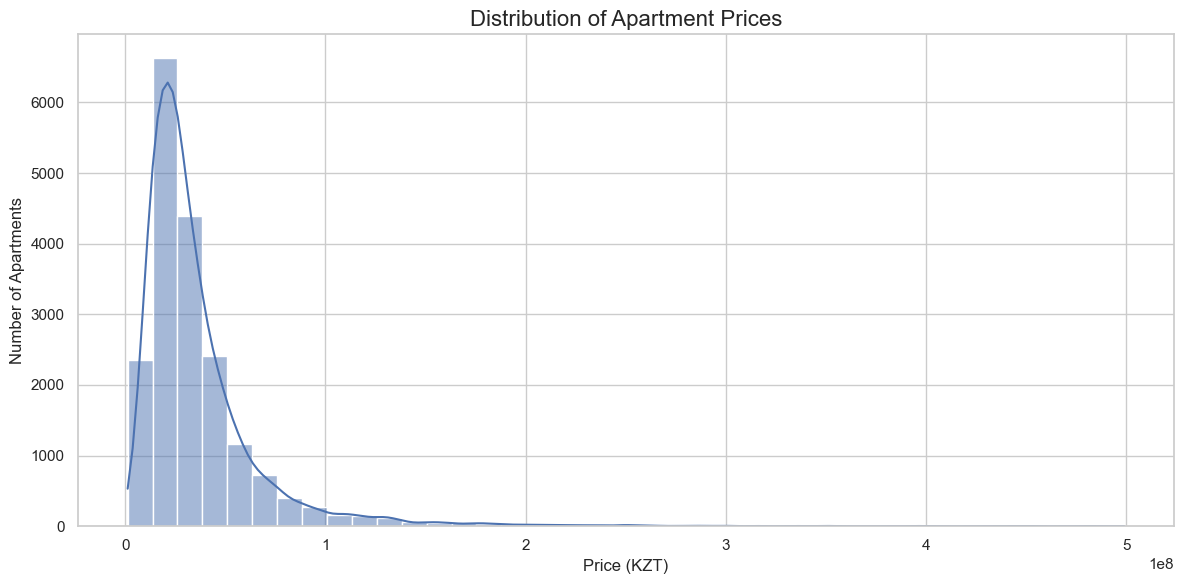

In [46]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Apartment Prices", fontsize=16)
plt.xlabel("Price (KZT)")
plt.ylabel("Number of Apartments")

plt.tight_layout()
plt.show()

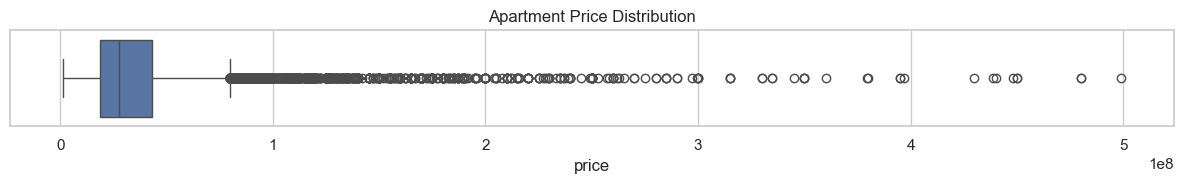

In [47]:
plt.figure(figsize=(12,2))

sns.boxplot(x=df["price"])

plt.title("Apartment Price Distribution")

plt.tight_layout()
plt.show()

2026-07-01 15:33:28,480 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-01 15:33:28,491 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


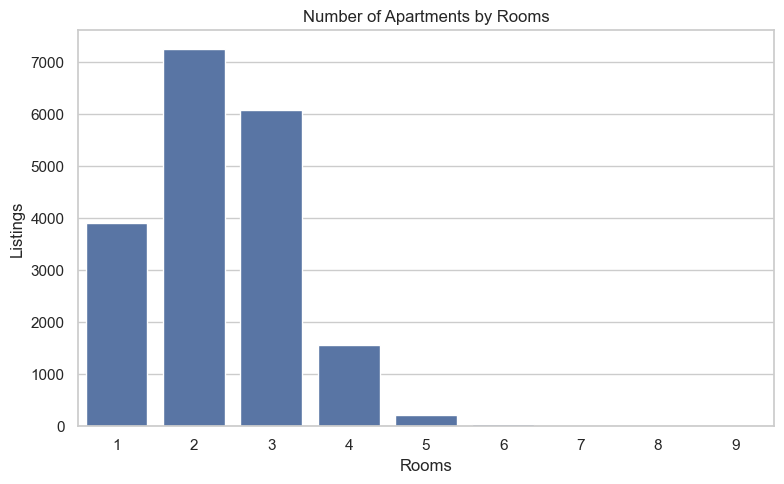

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="rooms",
    order=sorted(df["rooms"].unique())
)

plt.title("Number of Apartments by Rooms")
plt.xlabel("Rooms")
plt.ylabel("Listings")

plt.tight_layout()
plt.show()

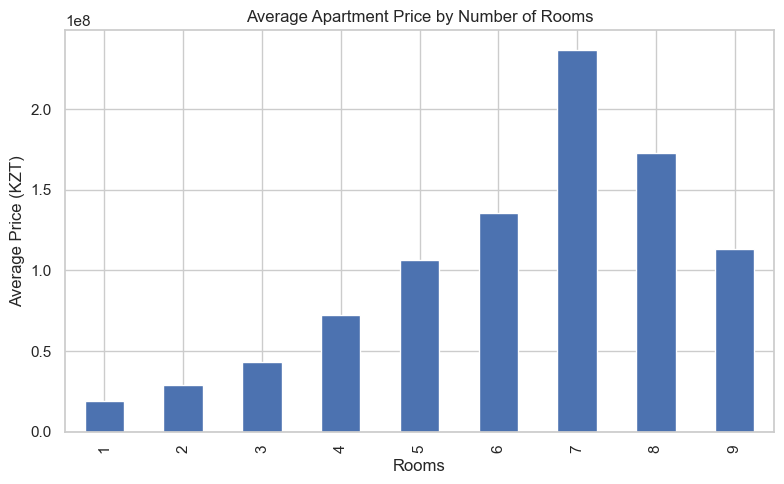

In [49]:
avg_price = (
    df.groupby("rooms")["price"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(8,5))

avg_price.plot(kind="bar")

plt.title("Average Apartment Price by Number of Rooms")
plt.xlabel("Rooms")
plt.ylabel("Average Price (KZT)")

plt.tight_layout()
plt.show()

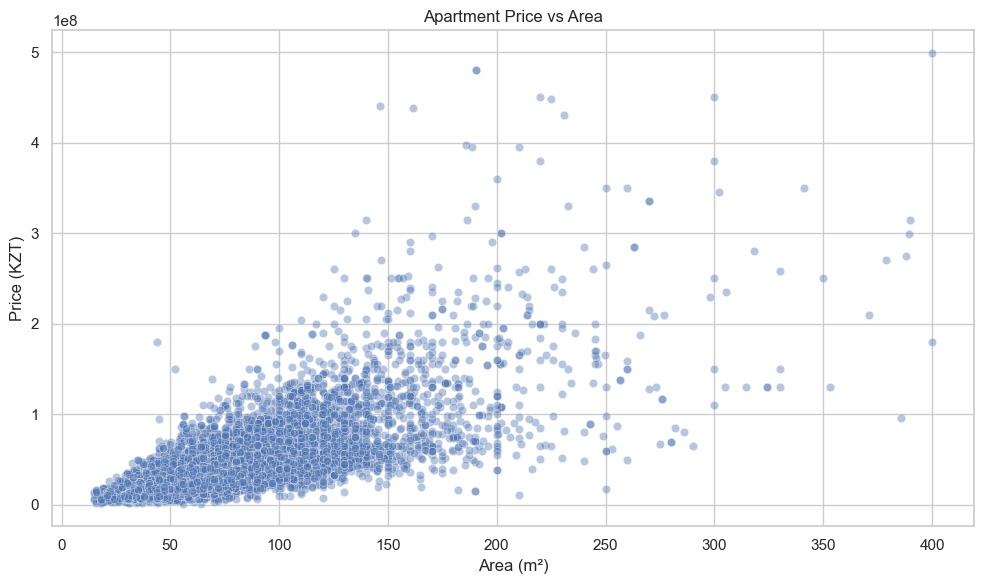

In [50]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="size_num",
    y="price",
    alpha=0.4
)

plt.title("Apartment Price vs Area")
plt.xlabel("Area (m²)")
plt.ylabel("Price (KZT)")

plt.tight_layout()
plt.show()

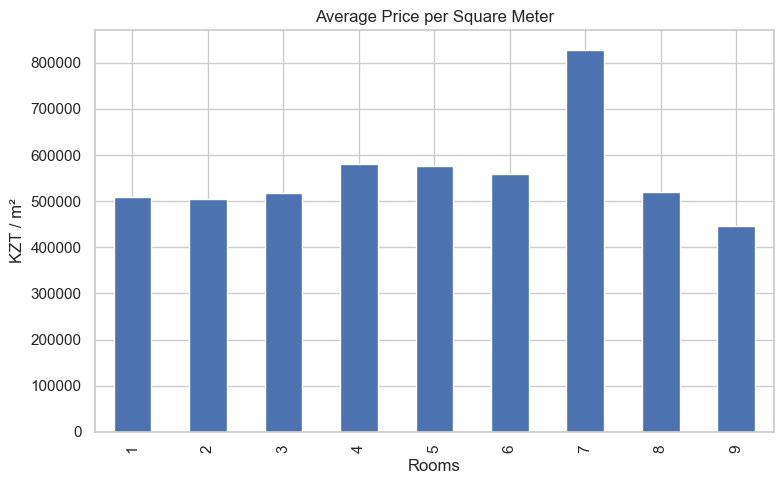

In [51]:
price_m2 = (
    df.groupby("rooms")["price_per_m2"]
      .mean()
      .sort_index()
)
plt.figure(figsize=(8,5))
price_m2.plot(kind="bar")

plt.title("Average Price per Square Meter")
plt.xlabel("Rooms")
plt.ylabel("KZT / m²")

plt.tight_layout()
plt.show()

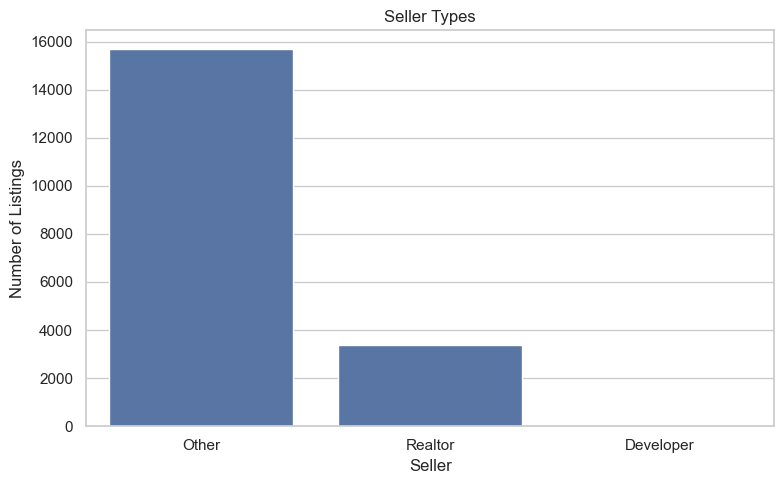

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="seller_type"
)
plt.title("Seller Types")
plt.xlabel("Seller")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

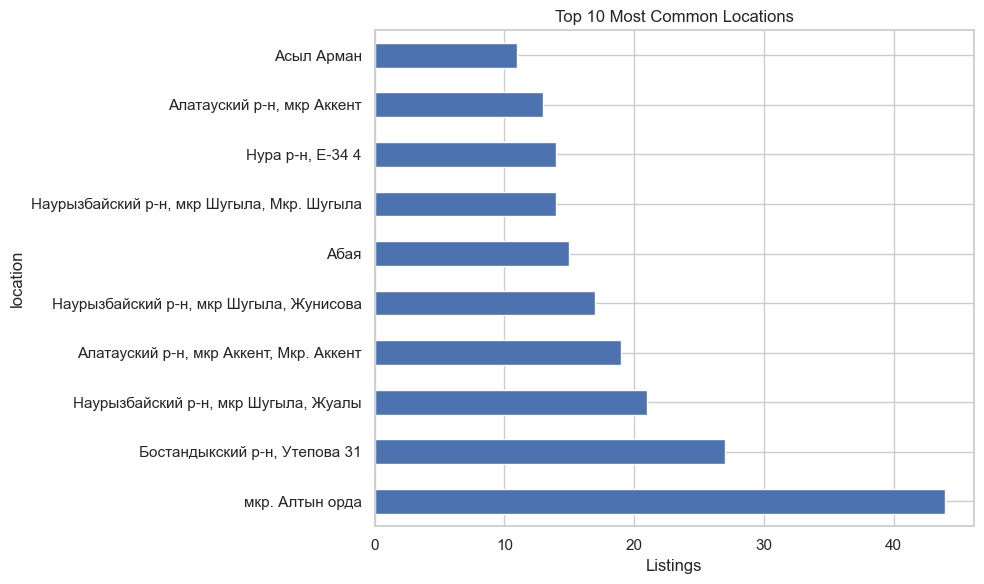

In [53]:
top_locations = (
    df["location"]
      .value_counts()
      .head(10)
)
plt.figure(figsize=(10,6))
top_locations.plot(kind="barh")
plt.title("Top 10 Most Common Locations")
plt.xlabel("Listings")
plt.tight_layout()
plt.show()

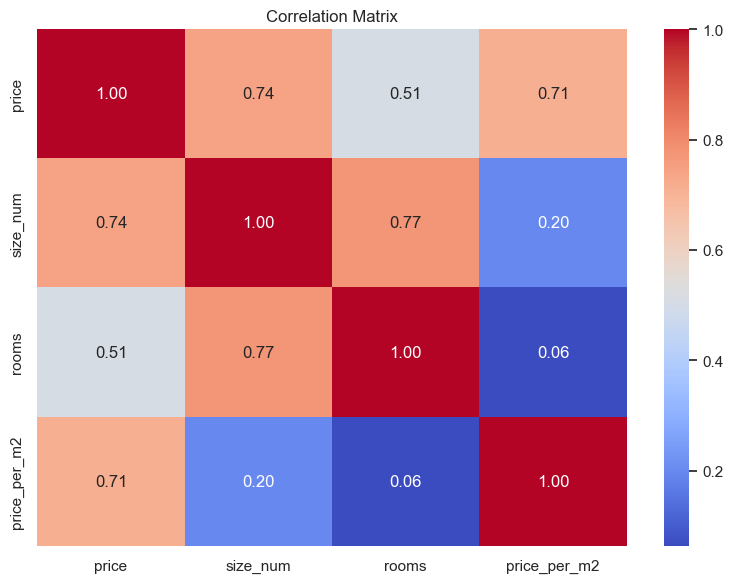

In [54]:
plt.figure(figsize=(8,6))
corr = df[
    [
        "price",
        "size_num",
        "rooms",
        "price_per_m2"
    ]
].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [55]:
print("DATASET SUMMARY")
print(f"Total apartments: {len(df):,}")
print(f"Average price: {df['price'].mean():,.0f} ₸")
print(f"Median price: {df['price'].median():,.0f} ₸")
print(f"Average area: {df['size_num'].mean():.1f} m²")
print(f"Average price per m²: {df['price_per_m2'].mean():,.0f} ₸")
print("\nApartments by rooms:")
print(df["rooms"].value_counts().sort_index())

DATASET SUMMARY
Total apartments: 19,082
Average price: 36,404,266 ₸
Median price: 27,500,000 ₸
Average area: 67.3 m²
Average price per m²: 517,046 ₸

Apartments by rooms:
rooms
1    3915
2    7247
3    6079
4    1559
5     213
6      47
7      12
8       7
9       3
Name: count, dtype: int64
